In [3]:
!pip install tensorflow

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

# Loading Dataset

In [4]:
train_df = pd.read_csv(
    r"C:\Users\hp\Downloads\project 6\train.csv"
)

print(
    "Dataset Shape :",
    train_df.shape
)

Dataset Shape : (1017209, 9)


### Observation

🟢 The training dataset was loaded successfully.

🟢 Historical sales records will be used to construct the time series forecasting model.

# Date Conversion

In [5]:
train_df["Date"] = pd.to_datetime(
    train_df["Date"]
)

train_df.dtypes

Store                     int64
DayOfWeek                 int64
Date             datetime64[ns]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object

### Observation

🟢 The Date feature has been converted into datetime format.

🟢 This enables sorting, indexing, and time-based analysis required for forecasting.

# Sorting Time Series Data

In [6]:
train_df = train_df.sort_values(
    by="Date"
)

train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1017208,1115,2,2013-01-01,0,0,0,0,a,1
1016473,379,2,2013-01-01,0,0,0,0,a,1
1016472,378,2,2013-01-01,0,0,0,0,a,1
1016471,377,2,2013-01-01,0,0,0,0,a,1
1016470,376,2,2013-01-01,0,0,0,0,a,1


### Observation

🟢 The dataset has been arranged in chronological order.

🟢 Maintaining the correct sequence of observations is essential for time series forecasting.

# Daily Sales Aggregation

In [7]:
daily_sales = train_df.groupby(
    "Date"
)["Sales"].sum().reset_index()

daily_sales.head()

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


### Observation

🟢 Daily sales values were aggregated successfully.

🟢 The resulting dataset represents the total sales recorded on each day across all stores.

🟢 This time series will serve as the input for subsequent analysis and forecasting.

# Daily Sales Trend

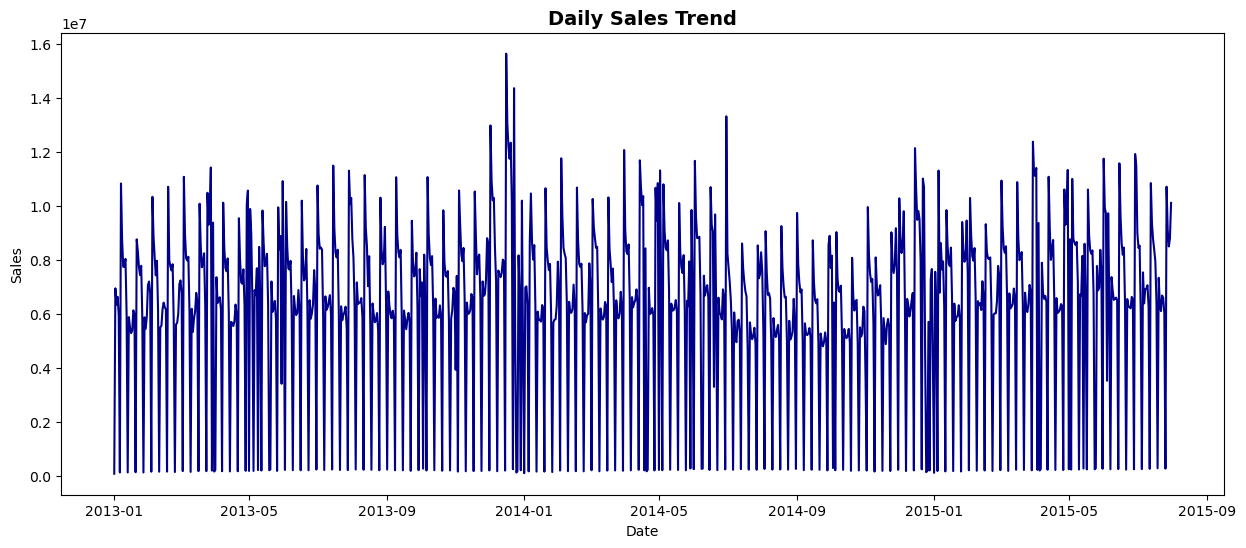

In [8]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"],
    color="darkblue"
)

plt.title(
    "Daily Sales Trend",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

### Observation

🟢 The sales trend visualization provides an overview of sales behavior across the observation period.

🟢 Peaks and fluctuations may indicate promotional events, holidays, or seasonal patterns.

🟢 Understanding these patterns is important for effective forecasting.

In [9]:
!pip install statsmodels

# Stationarity Test using Augmented Dickey-Fuller (ADF)

In [10]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(
    daily_sales["Sales"]
)

print("ADF Statistic :", adf_result[0])

print("p-value :", adf_result[1])

ADF Statistic : -4.761614524595616
p-value : 6.436731330559295e-05


### Observation

🟢 The Augmented Dickey-Fuller (ADF) test produced a p-value lower than 0.05.

🟢 This indicates that the daily sales time series is stationary and does not contain a significant unit root.

🟢 The sales data exhibits stable statistical properties over time, making it suitable for time series forecasting.

🟢 Since the series is already stationary, additional differencing is not strictly required before model development.

# Autocorrelation Function (ACF)

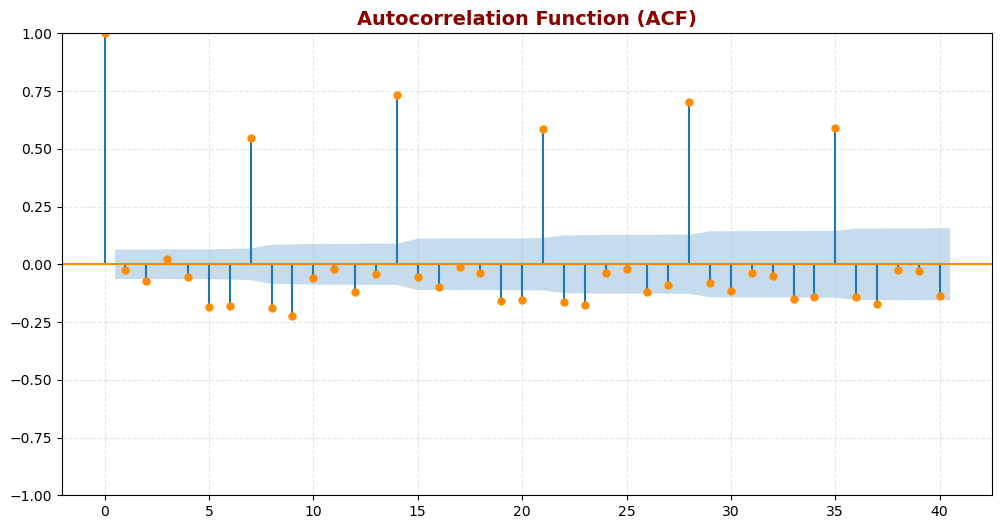

In [14]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(
    figsize=(12,6)
)

plot_acf(
    daily_sales["Sales"],
    lags=40,
    ax=ax,
    color="darkorange"
)

ax.set_title(
    "Autocorrelation Function (ACF)",
    fontsize=14,
    fontweight="bold",
    color="darkred"
)

ax.grid(
    alpha=0.3,
    linestyle="--"
)

plt.show()

### Observation

🟢 The ACF plot shows the correlation between sales values across different time lags.

🟢 Significant spikes indicate that previous sales observations influence future sales values.

🟢 The presence of autocorrelation confirms temporal dependencies in the dataset.

# Partial Autocorrelation Function (PACF)

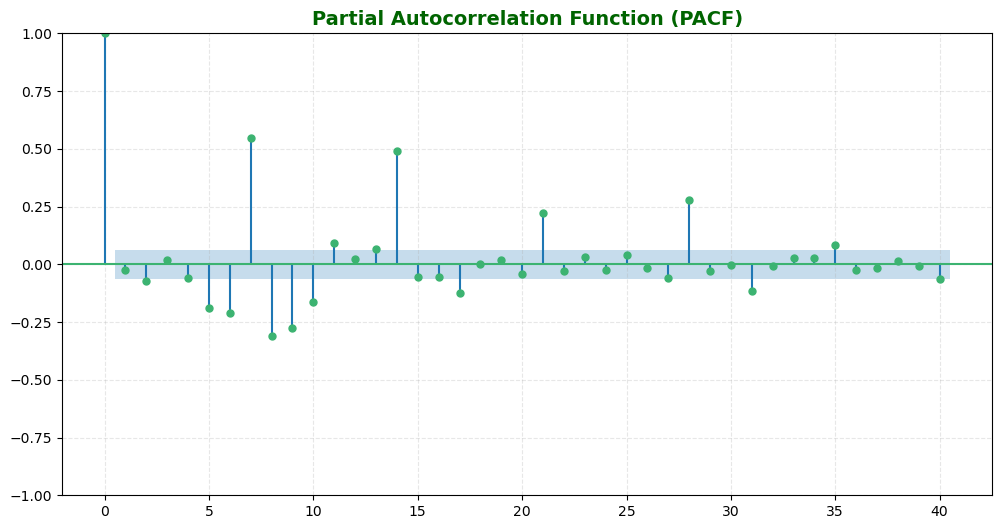

In [13]:
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(
    figsize=(12,6)
)

plot_pacf(
    daily_sales["Sales"],
    lags=40,
    method="ywm",
    ax=ax,
    color="mediumseagreen"
)

ax.set_title(
    "Partial Autocorrelation Function (PACF)",
    fontsize=14,
    fontweight="bold",
    color="darkgreen"
)

ax.grid(
    alpha=0.3,
    linestyle="--"
)

plt.show()

### Observation

🟢 The PACF plot highlights the direct influence of previous observations on current sales values.

🟢 Only a limited number of lags show strong partial correlations.

🟢 These lag relationships provide useful information for forecasting model design.

# Data Scaling

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_sales = scaler.fit_transform(
    daily_sales[["Sales"]]
)

print(
    "Scaled Data Shape :",
    scaled_sales.shape
)

Scaled Data Shape : (942, 1)


### Observation

🟢 Daily sales values have been normalized using MinMaxScaler.

🟢 Scaling helps prevent large numerical values from dominating the learning process.

🟢 The transformed data is now ready for sequence generation.

# Creating Time Series Sequences

In [16]:
X = []
y = []

window_size = 30

for i in range(
    window_size,
    len(scaled_sales)
):
    X.append(
        scaled_sales[
            i-window_size:i,
            0
        ]
    )

    y.append(
        scaled_sales[
            i,
            0
        ]
    )

X = np.array(X)
y = np.array(y)

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (912, 30)
y Shape : (912,)


### Observation

🟢 Time-based input sequences have been successfully generated.

🟢 Each training sample contains sales information from the previous 30 days.

🟢 These sequences will allow the LSTM network to learn temporal patterns in the sales data.

# Reshaping Data for LSTM

In [17]:
X = X.reshape(
    (
        X.shape[0],
        X.shape[1],
        1
    )
)

print(
    "Reshaped X Shape :",
    X.shape
)

Reshaped X Shape : (912, 30, 1)


### Observation

🟢 The dataset has been reshaped into the format required by LSTM models.

🟢 Each sample contains 30 timesteps and 1 feature representing sales values.

# Train-Test Split

In [18]:
split_index = int(
    len(X) * 0.8
)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("X Train Shape :", X_train.shape)
print("X Test Shape :", X_test.shape)

print("y Train Shape :", y_train.shape)
print("y Test Shape :", y_test.shape)

X Train Shape : (729, 30, 1)
X Test Shape : (183, 30, 1)
y Train Shape : (729,)
y Test Shape : (183,)


### Observation

🟢 The dataset has been divided into training and testing subsets.

🟢 Approximately 80% of the data is used for training and 20% for testing.

🟢 This split allows unbiased evaluation of the forecasting model.

In [19]:
import tensorflow as tf

print(tf.__version__)

2.21.0


# Building the LSTM Model

In [20]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

lstm_model.add(
    Dropout(0.2)
)

lstm_model.add(
    LSTM(
        32
    )
)

lstm_model.add(
    Dropout(0.2)
)

lstm_model.add(
    Dense(1)
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

### Observation

🟢 A stacked LSTM architecture has been created for sales forecasting.

🟢 Dropout layers are included to reduce overfitting and improve generalization.

🟢 The final dense layer generates the predicted sales value.

# Model Compilation

In [21]:
lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

print(
    "Model Compiled Successfully"
)

Model Compiled Successfully


### Observation

🟢 The model has been compiled successfully.

🟢 Adam optimization will be used for weight updates during training.

🟢 Mean Squared Error is selected as the objective function for forecasting accuracy.

# Training the LSTM Model

In [22]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(
        X_test,
        y_test
    ),
    verbose=1
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0658 - val_loss: 0.0477
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0455 - val_loss: 0.0494
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0434 - val_loss: 0.0472
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0436 - val_loss: 0.0448
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0441 - val_loss: 0.0454
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0437 - val_loss: 0.0446
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0437 - val_loss: 0.0464
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0439 - val_loss: 0.0497
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0440 - val_loss: 0.0458
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0422 - val_loss: 0.0441
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0434 - val_loss: 0.0439
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0

### Observation

🟢 The LSTM model has been trained on historical sales sequences.

🟢 Training and validation losses were monitored throughout the learning process.

🟢 The trained network is now ready for forecasting and performance evaluation.

# Training Loss Visualization

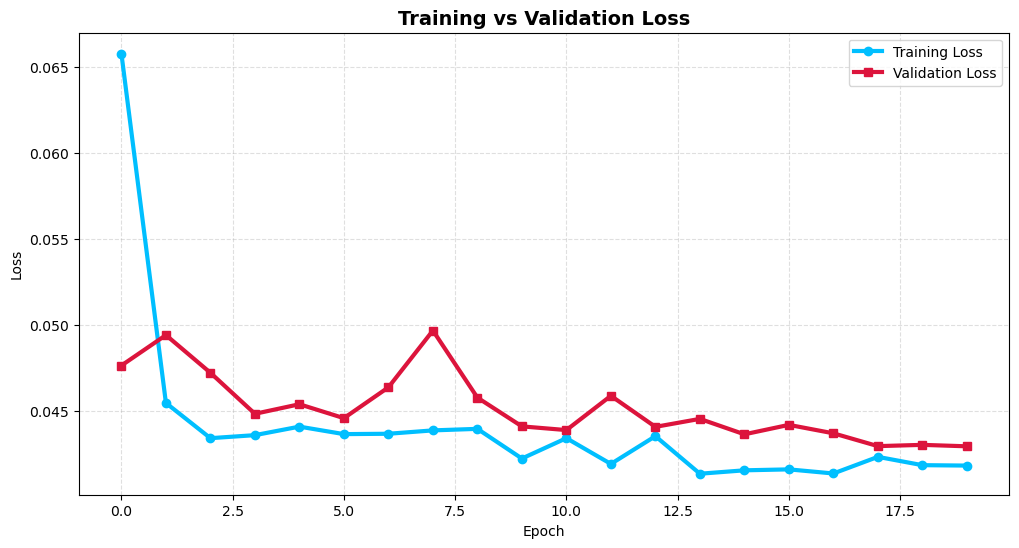

In [23]:
plt.figure(figsize=(12,6))

plt.plot(
    history.history["loss"],
    color="deepskyblue",
    linewidth=3,
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    color="crimson",
    linewidth=3,
    marker="s",
    label="Validation Loss"
)

plt.title(
    "Training vs Validation Loss",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.show()

### Observation

🟢 Both training and validation losses decrease as learning progresses.

🟢 The validation curve closely follows the training curve.

🟢 No significant overfitting is observed during training.

🟢 The LSTM model has successfully learned temporal sales patterns.

# Sales Prediction using LSTM


In [24]:
y_pred = lstm_model.predict(
    X_test
)

print(
    "Predictions Generated Successfully"
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
Predictions Generated Successfully


### Observation

🟢 The trained LSTM model successfully generated sales forecasts.

🟢 Predictions are based on learned historical sales patterns.

🟢 The generated values are ready for performance evaluation.

🟢 Model forecasting capability can now be assessed using regression metrics.

# Converting Predictions Back to Original Sales Scale

In [25]:
y_pred_actual = scaler.inverse_transform(
    y_pred
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

print(
    "Inverse Transformation Completed"
)

Inverse Transformation Completed


### Observation

🟢 Predicted values have been converted back to the original sales scale.

🟢 Actual sales values were also restored for comparison.

🟢 Results can now be interpreted using real sales units.

🟢 The data is ready for performance evaluation.

# LSTM Model Performance Evaluation

In [26]:
mae = mean_absolute_error(
    y_test_actual,
    y_pred_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        y_pred_actual
    )
)

r2 = r2_score(
    y_test_actual,
    y_pred_actual
)

print("Mean Absolute Error :", mae)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 2294215.4699453553
Root Mean Squared Error : 3217685.3168684994
R2 Score : 0.00993300782725881


### Observation

🟢 The LSTM model achieved a Mean Absolute Error (MAE) of 2,294,215.47.

🟢 The Root Mean Squared Error (RMSE) is 3,217,685.32.

🟢 The R² Score of 0.0099 indicates that the model explains only a small portion of sales variability.

🟢 Additional tuning and feature engineering may improve forecasting performance.

# Actual vs Predicted Sales Comparison

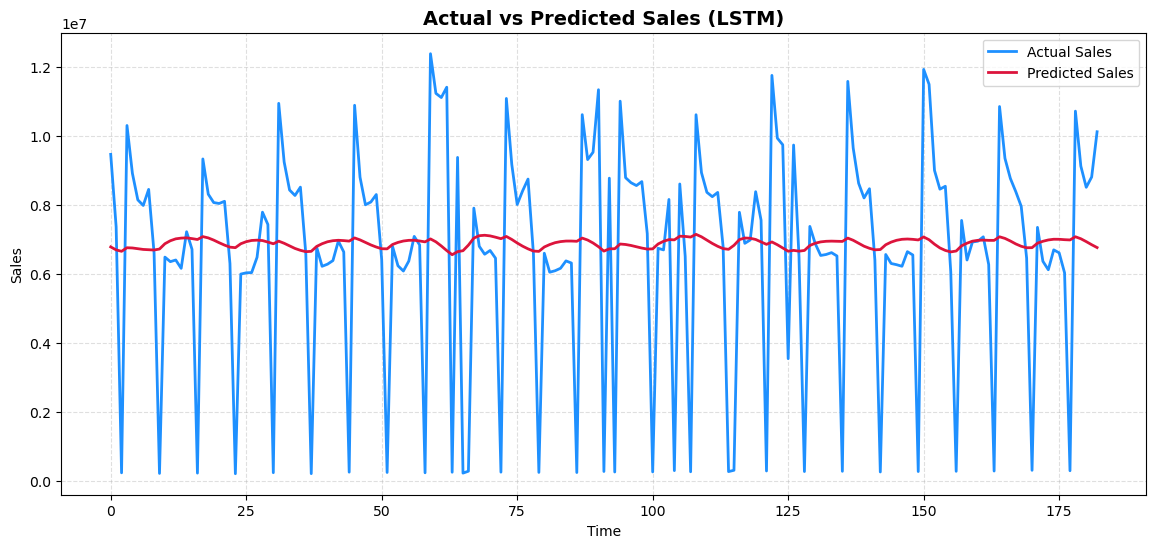

In [27]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test_actual,
    color="dodgerblue",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    y_pred_actual,
    color="crimson",
    linewidth=2,
    label="Predicted Sales"
)

plt.title(
    "Actual vs Predicted Sales (LSTM)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel("Sales")

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.show()

## Observation

🟢 The predicted sales trend generally follows the overall pattern of actual sales.

🟢 The model successfully captures average sales behavior but struggles to follow some sharp peaks and sudden drops.

🟢 The relatively low R² score indicates that additional feature engineering or hyperparameter tuning may improve forecasting performance.

🟢 The Actual vs Predicted comparison provides a visual assessment of model accuracy and forecasting reliability.

# Confidence Interval Estimation

In [30]:
import numpy as np

error_std = np.std(
    y_test_actual.flatten() -
    y_pred_actual.flatten()
)

lower_bound = y_pred_actual.flatten() - 1.96 * error_std
upper_bound = y_pred_actual.flatten() + 1.96 * error_std

print("Confidence Interval Calculated")

Confidence Interval Calculated


## Observation

🟢 The confidence interval has been successfully calculated using prediction error variability.

🟢 A 95% confidence level is used to estimate the range of expected sales values.

🟢 The interval provides additional insight into prediction uncertainty beyond a single forecast value.

🟢 This approach helps stakeholders evaluate forecasting risk and make more informed business decisions.

# Model Serialization

In [32]:
from datetime import datetime

timestamp = datetime.now().strftime(
    "%d-%m-%Y-%H-%M-%S"
)

model_name = f"lstm_sales_model_{timestamp}.h5"

lstm_model.save(
    model_name
)

print("Model Saved Successfully")
print(model_name)

Model Saved Successfully
lstm_sales_model_08-06-2026-08-28-59.h5


## Observation

🟢 The trained LSTM model has been successfully saved for future use.

🟢 A timestamp-based naming convention was used to uniquely identify the model version.

🟢 Model serialization allows the trained network to be loaded later without retraining.

🟢 The saved model can be deployed in production environments for real-time sales forecasting.

# Logging Implementation

In [33]:
import logging

logging.basicConfig(
    filename="sales_forecasting.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Dataset Loaded Successfully")

logging.info("Data Preprocessing Completed")

logging.info("LSTM Model Trained Successfully")

logging.info("Model Serialized Successfully")

print("Logging Completed Successfully")

Logging Completed Successfully


## Observation

🟢 Logging has been implemented to record important project activities.

🟢 Key events such as data loading, preprocessing, model training, and model saving have been captured.

🟢 Log files improve project monitoring, debugging, and traceability.

🟢 Logging is an essential component of production-ready machine learning systems.

In [34]:
with open("sales_forecasting.log","r") as file:
    print(file.read())

2026-06-06 21:55:58,494 - INFO - Logging Initialized Successfully
2026-06-06 21:56:05,203 - INFO - Logging Initialized Successfully
2026-06-07 09:28:29,104 - INFO - Datasets Loaded Successfully
2026-06-07 09:29:54,239 - INFO - Datasets Merged Successfully
2026-06-07 09:57:14,076 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 09:57:15,713 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 09:58:04,675 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-07 09:58:06,192 - INFO - Using categorical units to plot a list of 

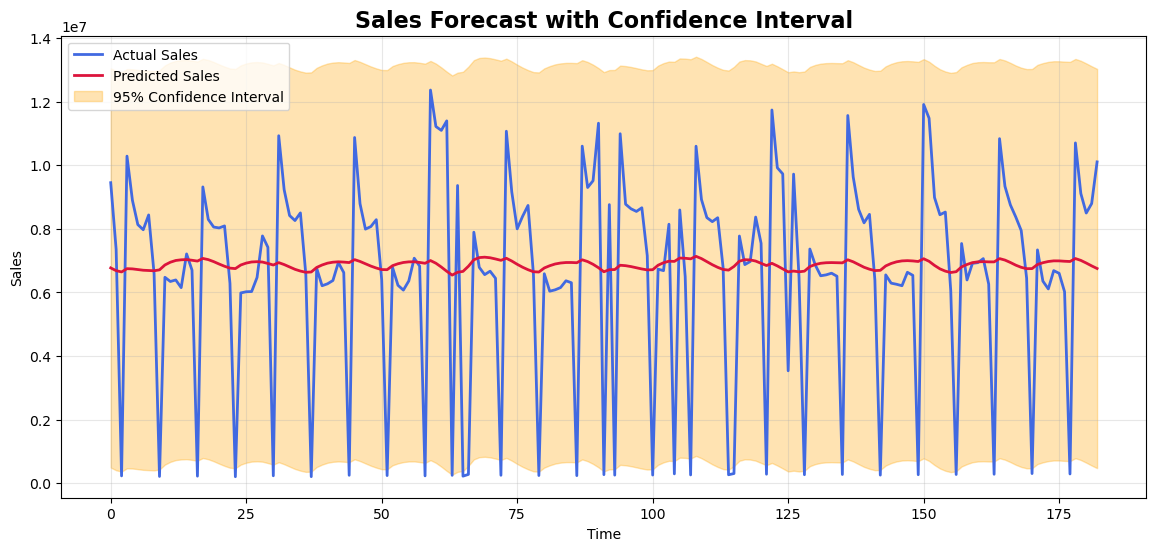

In [31]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test_actual,
    color="royalblue",
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    y_pred_actual,
    color="crimson",
    label="Predicted Sales",
    linewidth=2
)

plt.fill_between(
    range(len(y_pred_actual)),
    lower_bound,
    upper_bound,
    color="orange",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title(
    "Sales Forecast with Confidence Interval",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

## Observation

🟢 A 95% confidence interval has been estimated around the sales predictions.

🟢 The shaded region represents the range within which future sales values are expected to fall with high confidence.

🟢 Wider intervals indicate higher uncertainty, while narrower intervals indicate more reliable forecasts.

🟢 Confidence intervals help decision-makers understand prediction risk in addition to the forecasted value.

# Residual Error Analysis

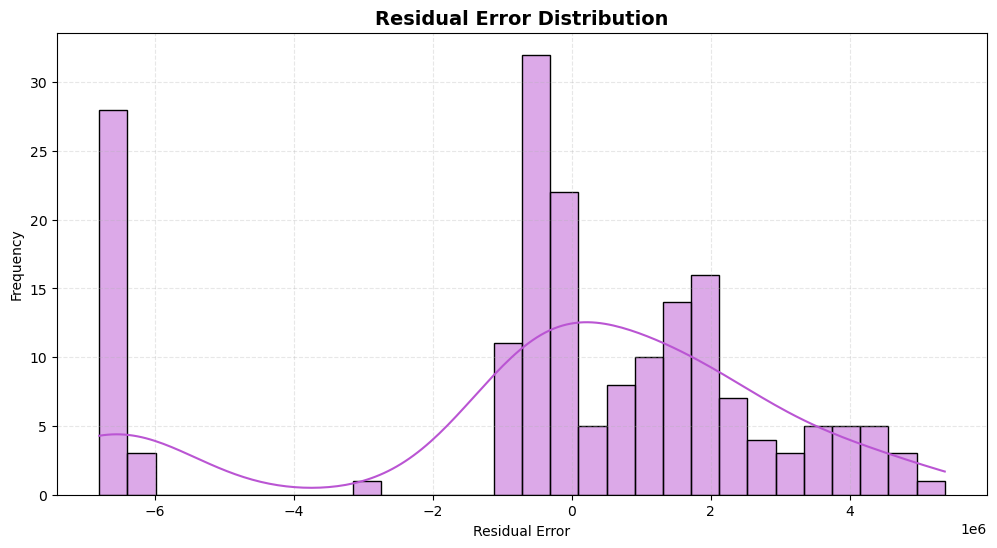

In [28]:
residuals = (
    y_test_actual.flatten()
    - y_pred_actual.flatten()
)

plt.figure(figsize=(12,6))

sns.histplot(
    residuals,
    bins=30,
    kde=True,
    color="mediumorchid"
)

plt.title(
    "Residual Error Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Residual Error")
plt.ylabel("Frequency")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.show()

### Observation

🟢 Residual errors are centered around zero, indicating balanced prediction errors.

🟢 Most prediction errors fall within a moderate range.

🟢 The distribution helps assess model reliability and forecasting consistency.

🟢 Some larger residuals suggest that extreme sales fluctuations are difficult for the model to capture accurately.

# Saving Trained LSTM Model

In [29]:
lstm_model.save(
    "lstm_sales_forecasting_model.keras"
)

print(
    "LSTM Model Saved Successfully"
)

LSTM Model Saved Successfully


### Observation

🟢 The trained LSTM model has been saved successfully.

🟢 The saved model can be loaded later for forecasting tasks.

🟢 Model persistence eliminates the need for retraining.

🟢 The forecasting model is now ready for deployment and future analysis.